## Phase 1 – Dataset Exploration

### Step 1: Import Required Libraries


In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Verify Dataset Path

In [2]:
dataset_path = Path("../datasets/plantvillage/color")

print("Dataset Path:", dataset_path)
print("Exists:", dataset_path.exists())

Dataset Path: ..\datasets\plantvillage\color
Exists: True


### Step 3: Listing Disease Classes

In [3]:
classes = sorted([folder.name for folder in dataset_path.iterdir() if folder.is_dir()])

print(f"Total Classes:{len(classes)}\n")

for cls in classes:
    print(cls)

Total Classes:38

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___health

### Step 4: Count Images per Class

Objective:
Calculate the total number of images available in every disease category.

Why?
Understanding the number of images in each class helps identify dataset imbalance before training the model. Balanced datasets generally produce better-performing machine learning models.

---


In [4]:
image_count = {}

for cls in classes:
    class_path = dataset_path/cls
    image_count[cls] = len(list(class_path.glob("*")))

for cls, count in image_count.items():
    print(f"{cls:<45} : {count}")

Apple___Apple_scab                            : 630
Apple___Black_rot                             : 621
Apple___Cedar_apple_rust                      : 275
Apple___healthy                               : 1645
Blueberry___healthy                           : 1502
Cherry_(including_sour)___Powdery_mildew      : 1052
Cherry_(including_sour)___healthy             : 854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 513
Corn_(maize)___Common_rust_                   : 1192
Corn_(maize)___Northern_Leaf_Blight           : 985
Corn_(maize)___healthy                        : 1162
Grape___Black_rot                             : 1180
Grape___Esca_(Black_Measles)                  : 1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)    : 1076
Grape___healthy                               : 423
Orange___Haunglongbing_(Citrus_greening)      : 5507
Peach___Bacterial_spot                        : 2297
Peach___healthy                               : 360
Pepper,_bell___Bacterial_spot                 : 9

### Step 5: Visualize Sample Images

Objective:
Visualize sample images from the PlantVillage dataset to understand the appearance of healthy and diseased crop leaves. This step helps verify image quality and provides a better understanding of the data before preprocessing and model training.

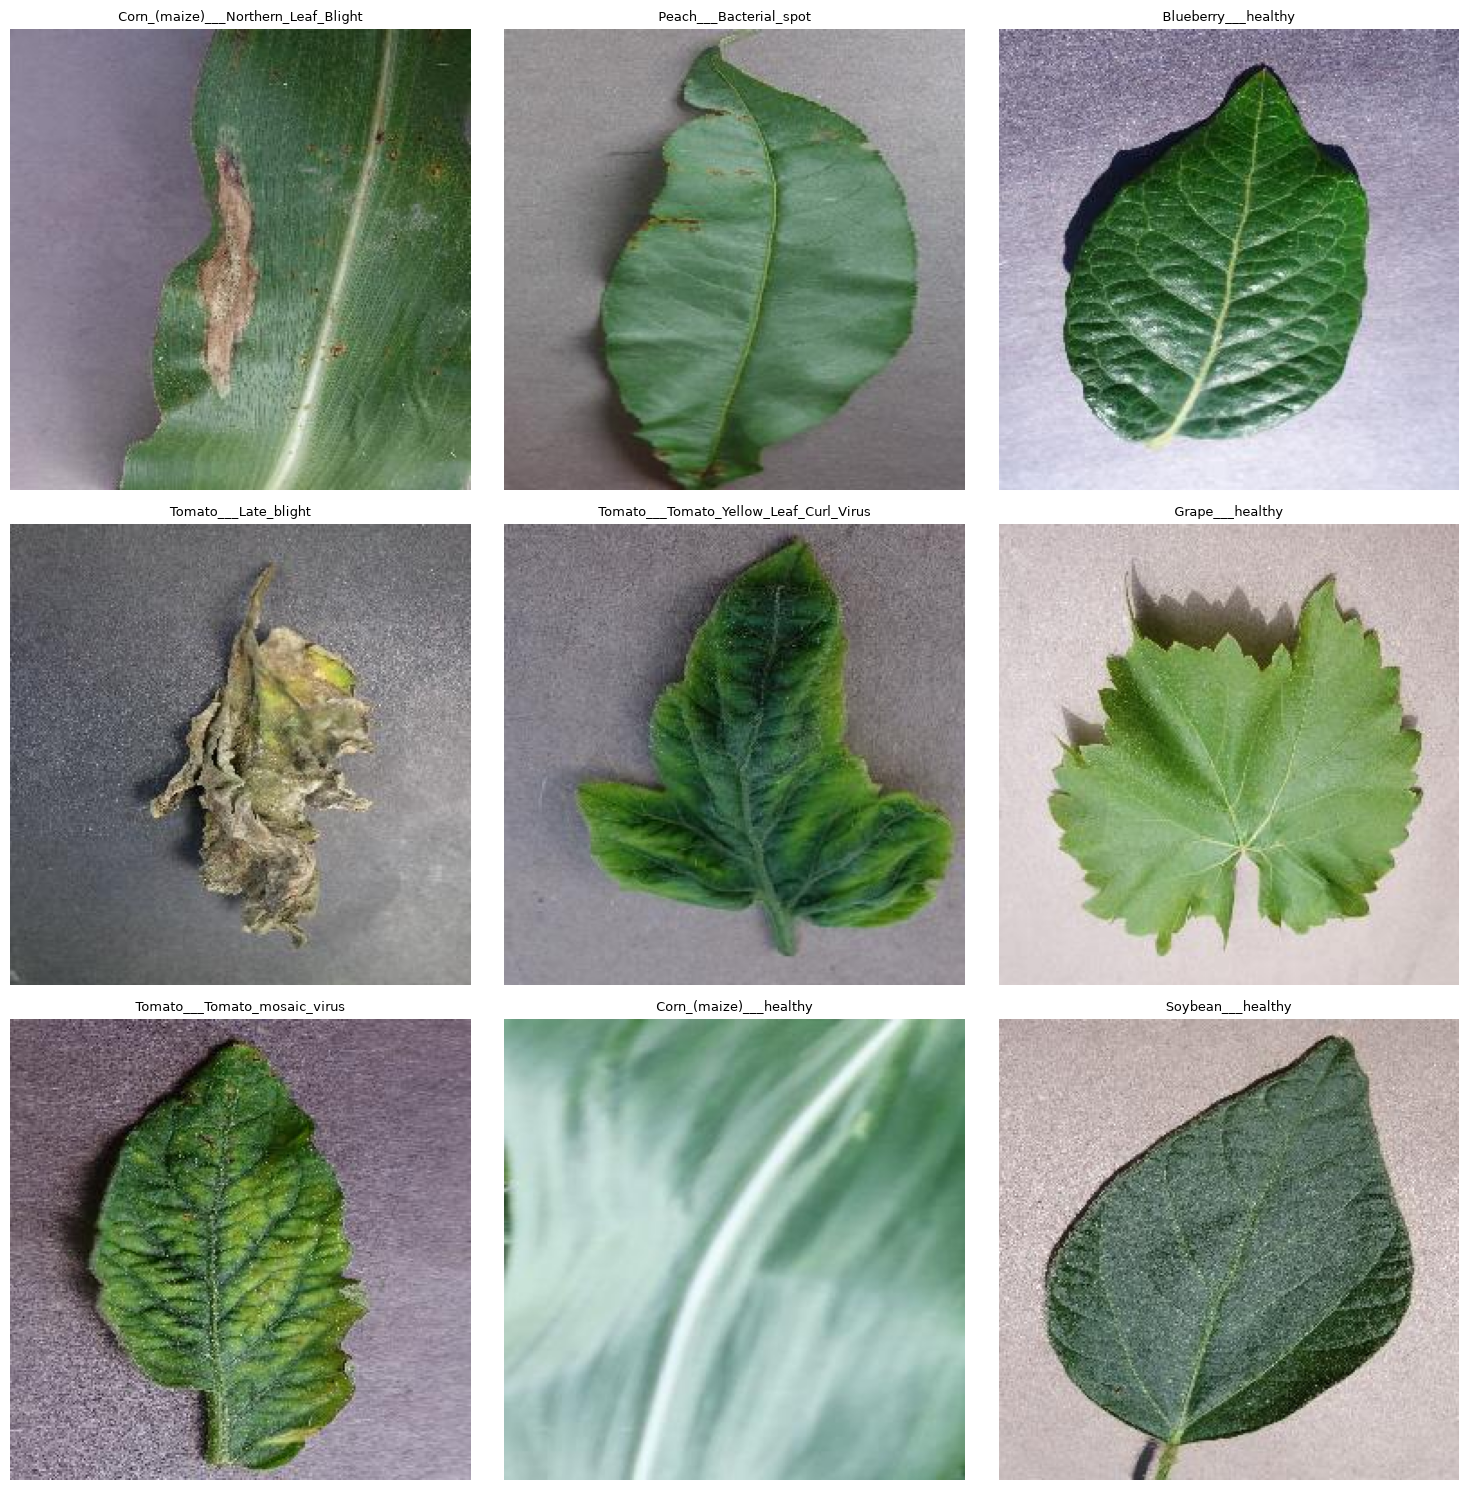

In [5]:
import random

sample_classes = random.sample(classes, 9)

plt.figure(figsize=(15, 15))

for i, cls in enumerate(sample_classes):
    class_path = dataset_path/cls
    images = list(class_path.glob("*"))
    image_path = random.choice(images)
    image =cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(cls, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Step 6: Explore Image Properties

Objective
Analyze the properties of a sample image, including its dimensions, shape, data type, and pixel value range. Understanding these properties helps determine the preprocessing steps required before training the deep learning model.

In [6]:
sample_class = classes[0]
sample_image_path = random.choice(list((dataset_path/sample_class).glob("*")))
image = cv2.imread(str(sample_image_path))

print("Class Name:",sample_class)
print("Image Name      :", sample_image_path.name)
print("Image Shape     :", image.shape)
print("Image Height    :", image.shape[0])
print("Image Width     :", image.shape[1])
print("Channels        :", image.shape[2])
print("Data Type       :", image.dtype)
print("Minimum Pixel   :", image.min())
print("Maximum Pixel   :", image.max())

Class Name: Apple___Apple_scab
Image Name      : 7bf25c0a-6594-4777-9a67-49a6487bb203___FREC_Scab 2993.JPG
Image Shape     : (256, 256, 3)
Image Height    : 256
Image Width     : 256
Channels        : 3
Data Type       : uint8
Minimum Pixel   : 0
Maximum Pixel   : 255


### Step 7: Verify Image Dimensions

Objective
Verify that all images in the PlantVillage dataset have consistent dimensions. Uniform image sizes simplify preprocessing and ensure compatibility with deep learning models.

In [7]:
image_sizes = {}
for cls in classes:
    class_path = dataset_path / cls
    for image_path in class_path.glob("*"):
        image = cv2.imread(str(image_path))
        if image is not None:
            size = image.shape
            image_sizes[size] = image_sizes.get(size, 0) + 1

print("Unique Image Sizes Found:\n")

for size, count in image_sizes.items():
    print(f"{size} : {count} images")

Unique Image Sizes Found:

(256, 256, 3) : 54305 images


### Step 8: Detect Corrupted Images

Objective
Verify that every image in the dataset can be read successfully. Detecting corrupted or unreadable images helps prevent errors during preprocessing and model training.

In [8]:
corrupted_images = []
for cls in classes:
    class_path = dataset_path/cls
    for image_path in class_path.glob("*"):
        image = cv2.imread(str(image_path))
        if image is None:
            corrupted_images.append(image_path)

print(f"Total Corrupted Images: {len(corrupted_images)}")

if len(corrupted_images) == 0:
    print("No corrupted images found")
else:
    print("\nCorrupted Images:")
    for img in corrupted_images:
        print(img)


Total Corrupted Images: 0
No corrupted images found


## Phase 2 – Dataset Preparation


### Step 9: Select Required Classes 
Objective

Select the required crop disease classes from the original PlantVillage dataset and prepare a separate dataset for the BKIS project. This ensures that the original dataset remains unchanged while creating a focused dataset for model training.

In [9]:
import shutil

source_path = Path("../datasets/plantvillage/color")

destination_path = Path("../datasets/bkis_dataset")

destination_path.mkdir(exist_ok=True)

selected_classes = [
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___healthy",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Potato___Early_blight",
    "Potato___healthy",
    "Potato___Late_blight",
    "Tomato___Early_blight",
    "Tomato___healthy",
    "Tomato___Late_blight"
]

print("Selected Classes:")

for cls in selected_classes:
    print(cls)

Selected Classes:
Corn_(maize)___Common_rust_
Corn_(maize)___healthy
Corn_(maize)___Northern_Leaf_Blight
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Tomato___Early_blight
Tomato___healthy
Tomato___Late_blight


### Step 10: Create BKIS Dataset

Objective

Copying only the selected crop disease folders into a new dataset. This preserves the original PlantVillage dataset and creates a dedicated dataset for BKIS model development.

In [10]:
for cls in selected_classes:
    source_folder = source_path/cls
    destination_folder = destination_path/cls

    if destination_folder.exists():
        print(f"Skipped:{cls} (Already Exists)")
    else:
        shutil.copytree(source_folder, destination_folder)
        print(f"Copied: {cls}")

print("\nBKIS Dataset Created")

Skipped:Corn_(maize)___Common_rust_ (Already Exists)
Skipped:Corn_(maize)___healthy (Already Exists)
Skipped:Corn_(maize)___Northern_Leaf_Blight (Already Exists)
Skipped:Potato___Early_blight (Already Exists)
Skipped:Potato___healthy (Already Exists)
Skipped:Potato___Late_blight (Already Exists)
Skipped:Tomato___Early_blight (Already Exists)
Skipped:Tomato___healthy (Already Exists)
Skipped:Tomato___Late_blight (Already Exists)

BKIS Dataset Created


### Step 11: Train, Validation & Test Split


In [11]:
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split

In [12]:
source_dataset = Path("../datasets/bkis_dataset")

split_dataset = Path("../datasets/split_dataset")

train_path = split_dataset / "train"
validation_path = split_dataset / "validation"
test_path = split_dataset / "test"

In [13]:
for folder in [train_path, validation_path, test_path]:
    folder.mkdir(parents=True, exist_ok=True)

print("Train Folder      :", train_path)
print("Validation Folder :", validation_path)
print("Test Folder       :", test_path)

Train Folder      : ..\datasets\split_dataset\train
Validation Folder : ..\datasets\split_dataset\validation
Test Folder       : ..\datasets\split_dataset\test


In [14]:
print("\nDirectory Status\n")

print("Source Dataset Exists      :", source_dataset.exists())
print("Split Dataset Exists       :", split_dataset.exists())
print("Train Folder Exists        :", train_path.exists())
print("Validation Folder Exists   :", validation_path.exists())
print("Test Folder Exists         :", test_path.exists())


Directory Status

Source Dataset Exists      : True
Split Dataset Exists       : True
Train Folder Exists        : True
Validation Folder Exists   : True
Test Folder Exists         : True


### Step 12: Split Dataset into Train, Validation & Test Sets

In [15]:
for class_folder in source_dataset.iterdir():

    if not class_folder.is_dir():
        continue

    class_name = class_folder.name

    images = list(class_folder.glob("*"))

    train_images, temp_images = train_test_split(
        images,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )
    validation_images, test_images = train_test_split(
        temp_images,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    (train_path / class_name).mkdir(parents=True, exist_ok=True)
    (validation_path / class_name).mkdir(parents=True, exist_ok=True)
    (test_path / class_name).mkdir(parents=True, exist_ok=True)

    for image in train_images:
        shutil.copy2(image, train_path / class_name / image.name)

    for image in validation_images:
        shutil.copy2(image, validation_path / class_name / image.name)

    for image in test_images:
        shutil.copy2(image, test_path / class_name / image.name)

    print(
        f"{class_name:<40} "
        f"Train: {len(train_images):4} | "
        f"Validation: {len(validation_images):4} | "
        f"Test: {len(test_images):4}"
    )

print("\nDataset split completed successfully!")

Corn_(maize)___Common_rust_              Train:  834 | Validation:  179 | Test:  179
Corn_(maize)___healthy                   Train:  813 | Validation:  174 | Test:  175
Corn_(maize)___Northern_Leaf_Blight      Train:  689 | Validation:  148 | Test:  148
Potato___Early_blight                    Train:  700 | Validation:  150 | Test:  150
Potato___healthy                         Train:  106 | Validation:   23 | Test:   23
Potato___Late_blight                     Train:  700 | Validation:  150 | Test:  150
Tomato___Early_blight                    Train:  700 | Validation:  150 | Test:  150
Tomato___healthy                         Train: 1113 | Validation:  239 | Test:  239
Tomato___Late_blight                     Train: 1336 | Validation:  286 | Test:  287

Dataset split completed successfully!


### Step 13: Verify Dataset Split

In [16]:
def count_images(folder):

    total = 0

    print(f"\n{folder.name.upper()} DATASET\n")

    for class_folder in sorted(folder.iterdir()):

        if class_folder.is_dir():

            count = len(list(class_folder.glob("*")))

            total += count

            print(f"{class_folder.name:<40} {count}")

    print(f"\nTotal Images : {total}")

count_images(train_path)

count_images(validation_path)

count_images(test_path)


TRAIN DATASET

Corn_(maize)___Common_rust_              834
Corn_(maize)___healthy                   813
Corn_(maize)___Northern_Leaf_Blight      689
Potato___Early_blight                    700
Potato___healthy                         106
Potato___Late_blight                     700
Tomato___Early_blight                    700
Tomato___healthy                         1113
Tomato___Late_blight                     1336

Total Images : 6991

VALIDATION DATASET

Corn_(maize)___Common_rust_              179
Corn_(maize)___healthy                   174
Corn_(maize)___Northern_Leaf_Blight      148
Potato___Early_blight                    150
Potato___healthy                         23
Potato___Late_blight                     150
Tomato___Early_blight                    150
Tomato___healthy                         239
Tomato___Late_blight                     286

Total Images : 1499

TEST DATASET

Corn_(maize)___Common_rust_              179
Corn_(maize)___healthy                   175
Corn_

### Step 14: Load Training, Validation & Test Datasets

In [55]:
train_dataset_path = train_path
validation_dataset_path = validation_path
test_dataset_path = test_path

In [56]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

In [57]:
import tensorflow as tf
train_dataset = tf.keras.utils.image_dataset_from_directory(

    train_dataset_path,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED)

Found 6991 files belonging to 9 classes.


In [58]:
class_names = train_dataset.class_names

print(class_names)

['Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']


In [59]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(

    validation_dataset_path,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED

)

Found 1499 files belonging to 9 classes.


In [60]:
test_dataset = tf.keras.utils.image_dataset_from_directory(

    test_dataset_path,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)

Found 1501 files belonging to 9 classes.


In [62]:
print("Training Batches   :", len(train_dataset))
print("Validation Batches :", len(validation_dataset))
print("Test Batches       :", len(test_dataset))

print("\nDetected Classes:")

for cls in train_dataset.class_names:
    print(cls)

print("\nTotal Classes :", len(train_dataset.class_names))

Training Batches   : 437
Validation Batches : 94
Test Batches       : 94

Detected Classes:
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato___Early_blight
Tomato___Late_blight
Tomato___healthy

Total Classes : 9


## Phase 3 – Image Preprocessing

### Step 15: Configure Performance Pipeline

In [63]:
AUTOTUNE = tf.data.AUTOTUNE

### Step 16: Normalize Images

In [64]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

In [65]:
train_dataset = train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

validation_dataset = validation_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

test_dataset = test_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

In [66]:
for images, labels in train_dataset.take(1):

    print("Minimum Pixel Value :", tf.reduce_min(images).numpy())
    print("Maximum Pixel Value :", tf.reduce_max(images).numpy())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


### Step 17: Data Augmentation

In [67]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.2),

    tf.keras.layers.RandomZoom(0.2),

    tf.keras.layers.RandomContrast(0.2)

])

### Step 18: Visualize Augmented Images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.36885148..1.0527].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.37634516..1.0245144].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.37353256..1.0282146].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.35944206..1.0440218].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.38434833..1.0130471].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3679869..1.0338461].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.38327968..1

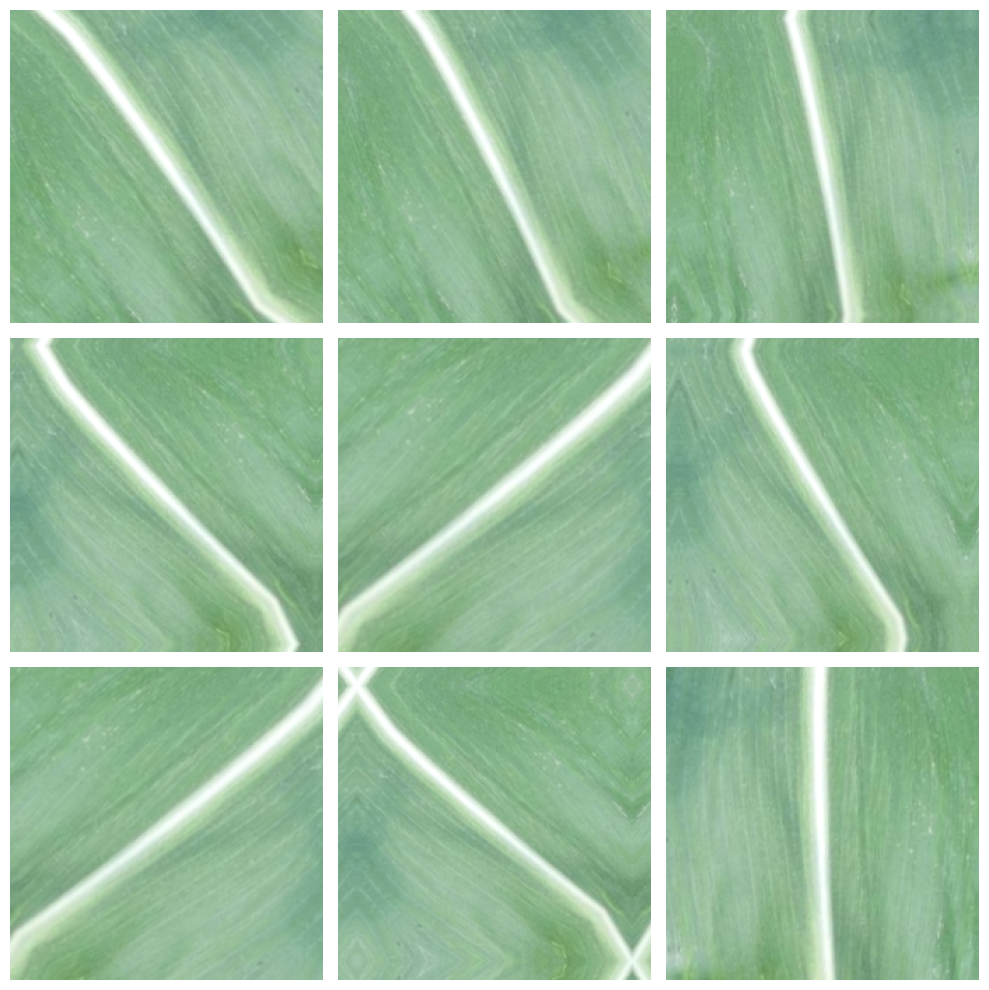

In [68]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    image = images[0]

    for i in range(9):

        augmented_image = data_augmentation(
            tf.expand_dims(image, axis=0),
            training=True
        )

        plt.subplot(3, 3, i + 1)

        plt.imshow(augmented_image[0].numpy())

        plt.axis("off")

plt.tight_layout()
plt.show()

## Phase 4: CNN Model Development

### Step 19: Build CNN Architecture

In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models


tf.keras.backend.clear_session()

model = models.Sequential([

    
    layers.Input(shape=(224, 224, 3)),

    
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    
    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(9, activation="softmax")
])

print("CNN Model Created Successfully")


CNN Model Created Successfully


### Step 20: Compile the CNN Model

In [30]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("Model Compiled Successfully")

Model Compiled Successfully


### Step 21: Display Model Summary

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,921 (433.29 KB)

 Trainable params: 110,921 (433.29 KB)

 Non-trainable params: 0 (0.00 B)

### Step 22: Configure Callbacks

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early Stopping
early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

# Save Best Model
model_checkpoint = ModelCheckpoint(

    filepath="../models/best_crop_disease_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

print("Callbacks Configured Successfully")

Callbacks Configured Successfully


### Step 23: Train CNN Model

In [33]:
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=25,

    callbacks=[
        early_stopping,
        model_checkpoint
    ],

    verbose=1

)

Epoch 1/25


c:\Users\HP\Desktop\BKIS\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.3665 - loss: 1.6414
Epoch 1: val_accuracy improved from None to 0.52835, saving model to ../models/best_crop_disease_model.keras

Epoch 1: finished saving model to ../models/best_crop_disease_model.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 359s 814ms/step - accuracy: 0.3665 - loss: 1.6414 - val_accuracy: 0.5284 - val_loss: 1.2223
Epoch 2/25
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 988ms/step - accuracy: 0.6184 - loss: 1.0353
Epoch 2: val_accuracy improved from 0.52835 to 0.73916, saving model to ../models/best_crop_disease_model.keras

Epoch 2: finished saving model to ../models/best_crop_disease_model.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 453s 1s/step - accuracy: 0.6184 - loss: 1.0353 - val_accuracy: 0.7392 - val_loss: 0.6615
Epoch 3/25
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7162 - loss: 0.7461
Epoch 3: val_accuracy improved from 0.73916 to 0.81721, saving model to ../models/best_crop_disease_model.keras

Epoch 3: finished saving mo

## Phase 5: Model Evaluation

### Step 24: Plot Training History

In [70]:
import matplotlib.pyplot as plt

train_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

epochs = range(1, len(train_accuracy) + 1)

### Plot Accuracy

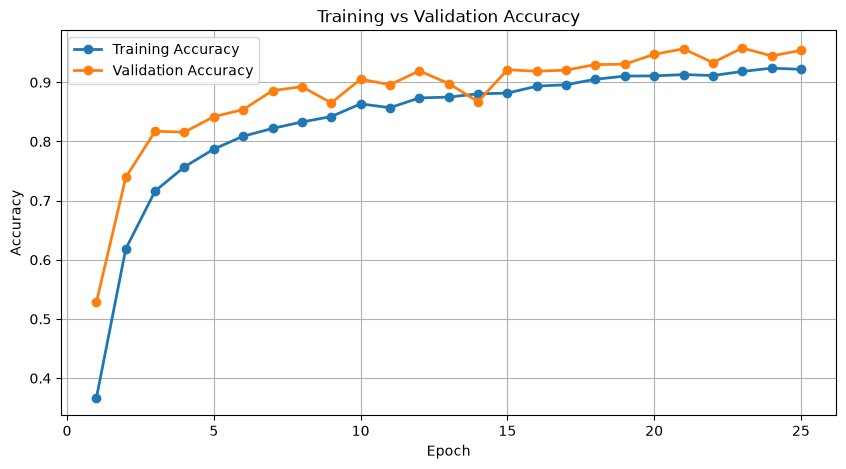

In [71]:
plt.figure(figsize=(10,5))

plt.plot(
    epochs,
    train_accuracy,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    validation_accuracy,
    marker="o",
    linewidth=2,
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.legend()

plt.show()

### Plot Loss

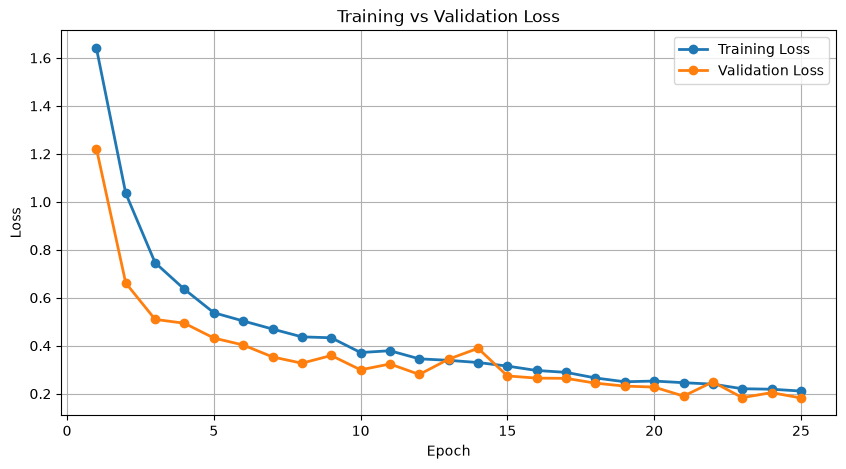

In [72]:
plt.figure(figsize=(10,5))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.show()

### Step 25: Evaluate Model on Test Dataset

In [73]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 239ms/step - accuracy: 0.9534 - loss: 0.1467

Test Loss     : 0.1467
Test Accuracy : 95.34%


### Step 26: Generate Predictions

In [76]:
import numpy as np

predictions = model.predict(test_dataset)

predicted_labels = np.argmax(predictions, axis=1)

print("Prediction Shape :", predictions.shape)
print("Predicted Labels :", predicted_labels.shape)

true_labels = np.concatenate(

    [labels.numpy() for _, labels in test_dataset],

    axis=0

)

print("True Labels :", true_labels.shape)

print("\nClass Names:")
print(class_names)


94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 254ms/step
Prediction Shape : (1501, 9)
Predicted Labels : (1501,)
True Labels : (1501,)

Class Names:
['Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']


### Step 27: Generate Confusion Matrix

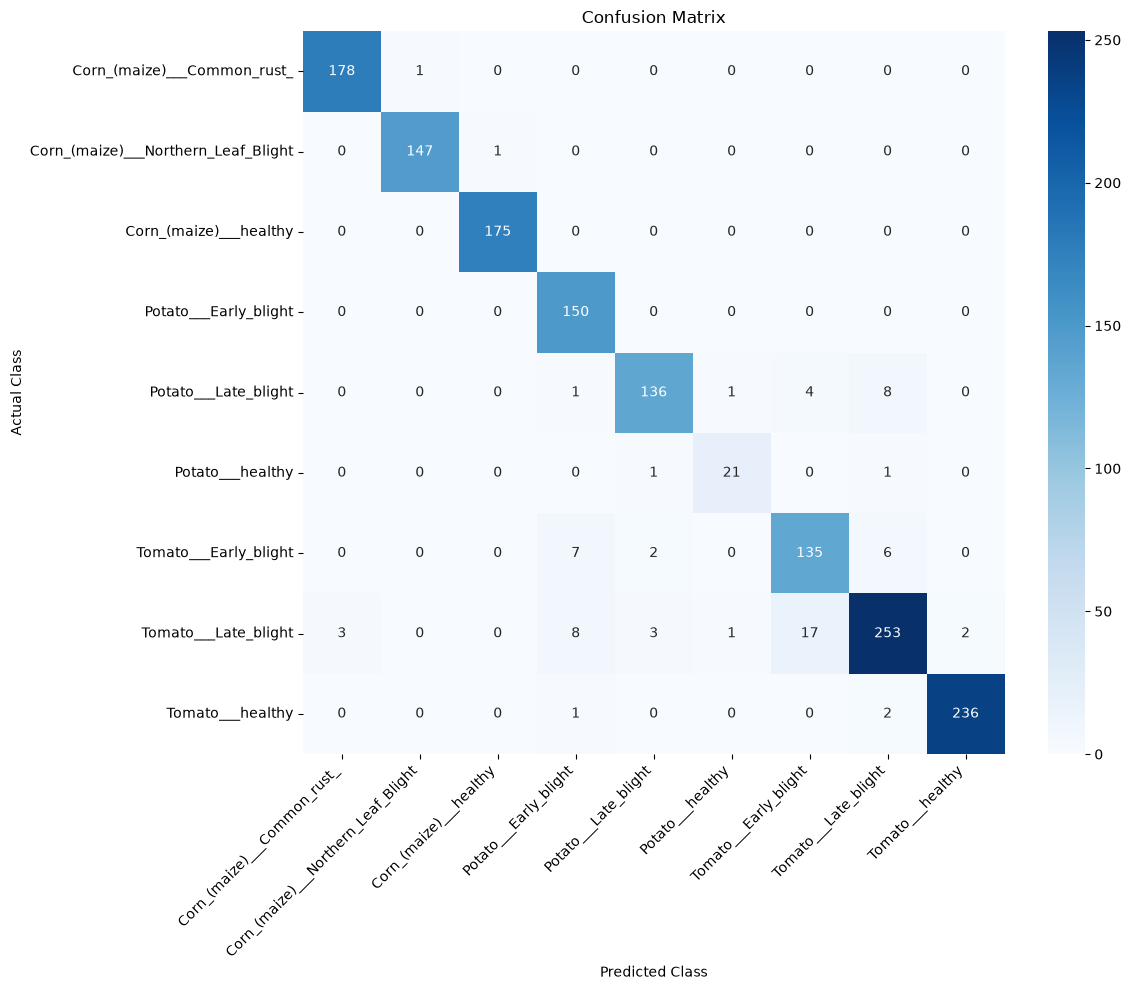

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

### Step 28: Generate Classification Report

In [78]:
from sklearn.metrics import classification_report

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names,
    digits=4
)

print(report)

                                     precision    recall  f1-score   support

        Corn_(maize)___Common_rust_     0.9834    0.9944    0.9889       179
Corn_(maize)___Northern_Leaf_Blight     0.9932    0.9932    0.9932       148
             Corn_(maize)___healthy     0.9943    1.0000    0.9972       175
              Potato___Early_blight     0.8982    1.0000    0.9464       150
               Potato___Late_blight     0.9577    0.9067    0.9315       150
                   Potato___healthy     0.9130    0.9130    0.9130        23
              Tomato___Early_blight     0.8654    0.9000    0.8824       150
               Tomato___Late_blight     0.9370    0.8815    0.9084       287
                   Tomato___healthy     0.9916    0.9874    0.9895       239

                           accuracy                         0.9534      1501
                          macro avg     0.9482    0.9529    0.9501      1501
                       weighted avg     0.9541    0.9534    0.9532      15

### Saving Model

In [79]:
import json

model.save("../models/best_crop_disease_model.keras")

with open("../models/class_names.json", "w") as file:
    json.dump(class_names, file, indent=4)

print("Model saved successfully!")
print("Class names saved successfully!")

Model saved successfully!
Class names saved successfully!
